# Generative Modelling on CIFAR-10
<!-- **Author:** Swayam &nbsp;|&nbsp; **Group:** Diffusion Models -->

This notebook fine-tunes a pretrained DDPM (`google/ddpm-cifar10-32` from the
Hugging Face Hub) on CIFAR-10, then runs two ablation studies:

1. **Noise schedule**: linear vs. cosine beta schedule
2. **Inference speed**: full DDPM (1000 steps) vs. DDIM (10/50/200 steps)


In [1]:
!pip install -r requirements.txt

import sys
sys.path.insert(0, '/content')  # so the src imports work

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.5 MB/s eta 0:00:00
  Attempting uninstall: jupyter-server
    Found existing installation: jupyter_server 2.18.2
    Uninstalling jupyter_server-2.18.2:
      Successfully uninstalled jupyter_server-2.18.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires jupyter-server==2.18.2, but you have jupyter-server 2.20.0 which is incompatible.


## 0. Setup

In [2]:
!pip install -q diffusers torchvision

import sys
sys.path.insert(0, "/content")  # files uploaded flat to /content/

import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 1. Data Exploration

Class distribution, sample images, and basic dataset statistics for CIFAR-10.

100%|██████████| 170M/170M [06:36<00:00, 430kB/s]


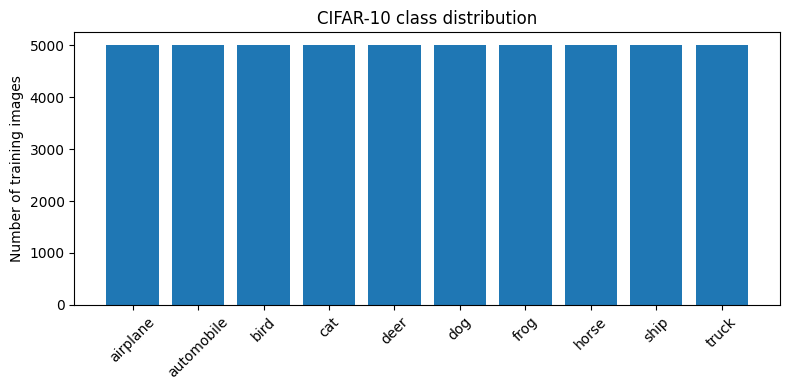

{'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


In [3]:
from data_utils import analyze_class_distribution, get_cifar10, show_sample_grid

counts = analyze_class_distribution(root="./data", download=True)
print(counts)

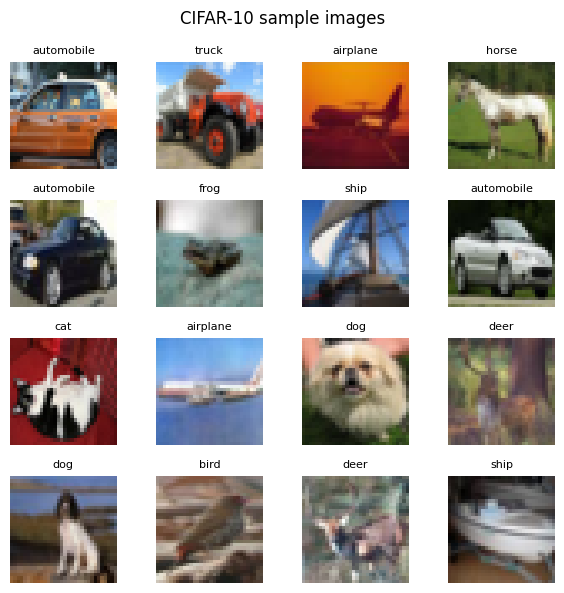

Image shape: torch.Size([3, 32, 32]) | value range: [-1, 1] after normalization


In [4]:
train_set = get_cifar10(root="./data", train=True, download=True)
show_sample_grid(train_set, n=16, title="CIFAR-10 sample images")
print("Image shape:", train_set[0][0].shape, "| value range: [-1, 1] after normalization")

**Observations to record in the report:** CIFAR-10 is perfectly class-balanced
(6,000 images/class). Images are tiny (32x32), so the generative task is more about
texture/shape fidelity at low resolution than fine detail. Intra-class variation is
high for natural categories like `bird`, `cat`, `dog`; lower for rigid man-made
categories like `automobile`, `truck`, `airplane`.

## 2. Baseline Generation (pretrained, no fine-tuning)

Load the pretrained DDPM checkpoint and generate samples *before* any fine-tuning,
as a baseline reference point.

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomm

config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/143M [00:00<?, ?B/s]

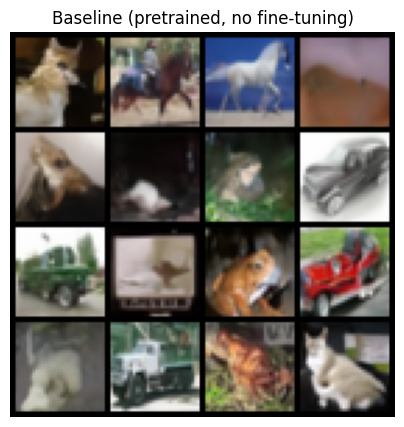

In [5]:
from model import DiffusionModel
from data_utils import tensor_to_image_grid

baseline_model = DiffusionModel(schedule="linear", num_timesteps=1000,
                                 pretrained=True, device=device)
baseline_model.eval()

baseline_samples = baseline_model.sample_ddim(num_images=16, num_inference_steps=50)
grid = tensor_to_image_grid(baseline_samples, nrow=4)
plt.figure(figsize=(5, 5)); plt.imshow(grid); plt.axis("off")
plt.title("Baseline (pretrained, no fine-tuning)")
plt.savefig("baseline_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Fine-Tuning — Ablation 1: Noise Schedule (linear vs. cosine)

fine-tuned two copies of the same pretrained backbone, one with a linear beta
schedule and one with a cosine schedule, keeping every other hyperparameter fixed.
This isolates the effect of the noise schedule on training stability and sample
quality.

In [6]:
!python train.py --schedule linear --epochs 5 --batch_size 64 --lr 1e-5 --output_dir outputs

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Using device: cuda
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
[linear] epoch 0 step 0 loss 0.0309  lr 1.00e-05
[linear] epoch 0 step 50 loss 0.0264  lr 1.00e-05
[linear] epoch 0 step 100 loss 0.0314  lr 9.98e-06
[linear] epoch 0 step 150 loss 0.0275  lr 9.96e-06
[linear] epoch 0 step 200 loss 0.0185  lr 9.94e-06
[linear] epoch 0 step 250 loss 0.0277  lr 9.90e-06
[linear] epoch 0 step 300 loss 0.0231  lr 9.86e-06
[linear] epoch 0 step 350 loss 0.0358  lr 9.81e-06
[linear] epoch 0

In [7]:
!python train.py --schedule cosine --epochs 5 --batch_size 64 --lr 1e-5 --output_dir outputs

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Using device: cuda
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
[cosine] epoch 0 step 0 loss 0.1441  lr 1.00e-05
[cosine] epoch 0 step 50 loss 0.0833  lr 1.00e-05
[cosine] epoch 0 step 100 loss 0.0812  lr 9.98e-06
[cosine] epoch 0 step 150 loss 0.0817  lr 9.96e-06
[cosine] epoch 0 step 200 loss 0.0436  lr 9.94e-06
[cosine] epoch 0 step 250 loss 0.0551  lr 9.90e-06
[cosine] epoch 0 step 300 loss 0.0552  lr 9.86e-06
[cosine] epoch 0 step 350 loss 0.0648  lr 9.81e-06
[cosine] epoch 0

### Compare training loss curves

In [8]:
import os
os.makedirs("outputs", exist_ok=True)

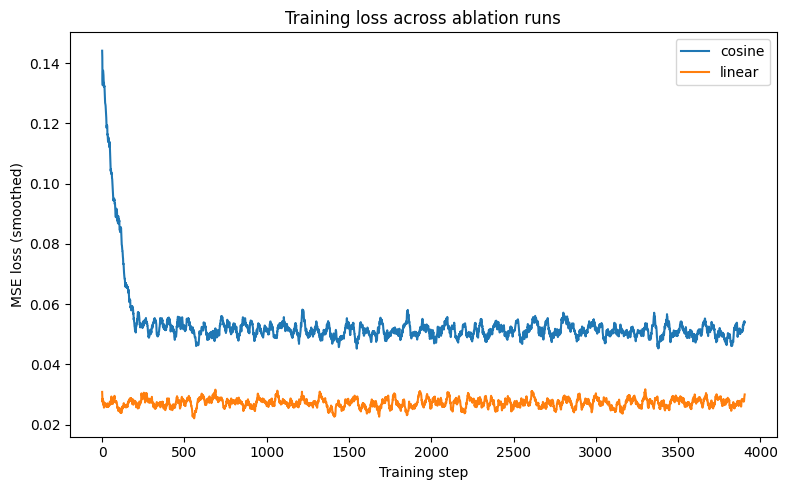

Saved comparison plot to outputs/loss_comparison.png


In [9]:
from evaluate import compare_loss_curves
compare_loss_curves(history_glob="outputs/loss_*.json", save_path="outputs/loss_comparison.png")

## 4. Generate from each fine-tuned model and compare visually

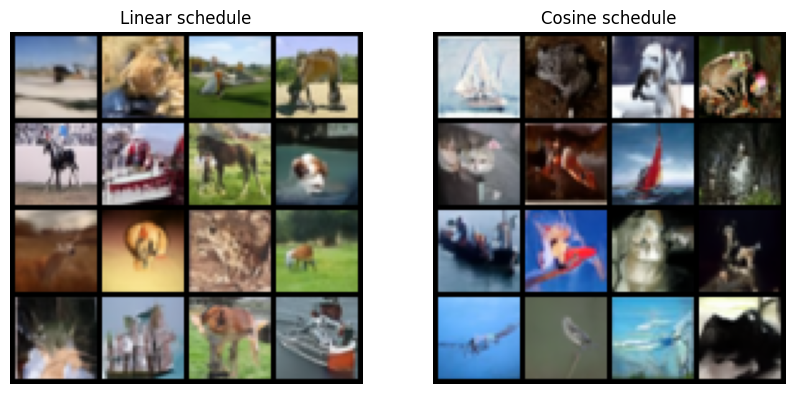

In [10]:
linear_model = DiffusionModel(schedule="linear", num_timesteps=1000, pretrained=True, device=device)
linear_model.unet.load_state_dict(torch.load("outputs/unet_linear.pt", map_location=device))
linear_model.eval()

cosine_model = DiffusionModel(schedule="cosine", num_timesteps=1000, pretrained=True, device=device)
cosine_model.unet.load_state_dict(torch.load("outputs/unet_cosine.pt", map_location=device))
cosine_model.eval()

linear_samples = linear_model.sample_ddim(num_images=16, num_inference_steps=50)
cosine_samples = cosine_model.sample_ddim(num_images=16, num_inference_steps=50)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(tensor_to_image_grid(linear_samples, nrow=4)); axes[0].set_title("Linear schedule"); axes[0].axis("off")
axes[1].imshow(tensor_to_image_grid(cosine_samples, nrow=4)); axes[1].set_title("Cosine schedule"); axes[1].axis("off")
plt.savefig("outputs/schedule_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
from evaluate import diversity_score, inception_distance
from data_utils import get_cifar10
import torch

real_batch = torch.stack([get_cifar10(download=False)[i][0] for i in range(16)])

print("Diversity (linear):", diversity_score(linear_samples))
print("Diversity (cosine):", diversity_score(cosine_samples))

# NOTE: with only 16 samples this is a *relative*, noisy signal -- not a
# paper-comparable FID score. Useful only to compare our two runs against each other.
print("Inception distance (linear):", inception_distance(real_batch, linear_samples, device=device))
print("Inception distance (cosine):", inception_distance(real_batch, cosine_samples, device=device))

Diversity (linear): 35.24828338623047
Diversity (cosine): 42.40669250488281
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 203MB/s]


Inception distance (linear): 4.316956996917725
Inception distance (cosine): 4.856573581695557


## 5. Ablation 2: Inference Speed — DDPM vs. DDIM

Using the better of the two fine-tuned models from Ablation 1, compare:
- Full DDPM sampling (1000 steps)
- DDIM sampling at 200 / 50 / 10 steps

for both **wall-clock generation time** and **visual quality**.

In [12]:
import time

best_model = cosine_model  # change to linear_model if that schedule looked better above

results = {}

t0 = time.time()
ddpm_samples = best_model.sample_ddpm(num_images=16)
results["ddpm_1000"] = (time.time() - t0, ddpm_samples)

for n_steps in [200, 50, 10]:
    t0 = time.time()
    s = best_model.sample_ddim(num_images=16, num_inference_steps=n_steps)
    results[f"ddim_{n_steps}"] = (time.time() - t0, s)

for name, (elapsed, _) in results.items():
    print(f"{name}: {elapsed:.2f}s total, {elapsed/16:.3f}s/image")

ddpm_1000: 50.54s total, 3.159s/image
ddim_200: 9.94s total, 0.621s/image
ddim_50: 2.47s total, 0.154s/image
ddim_10: 0.49s total, 0.031s/image


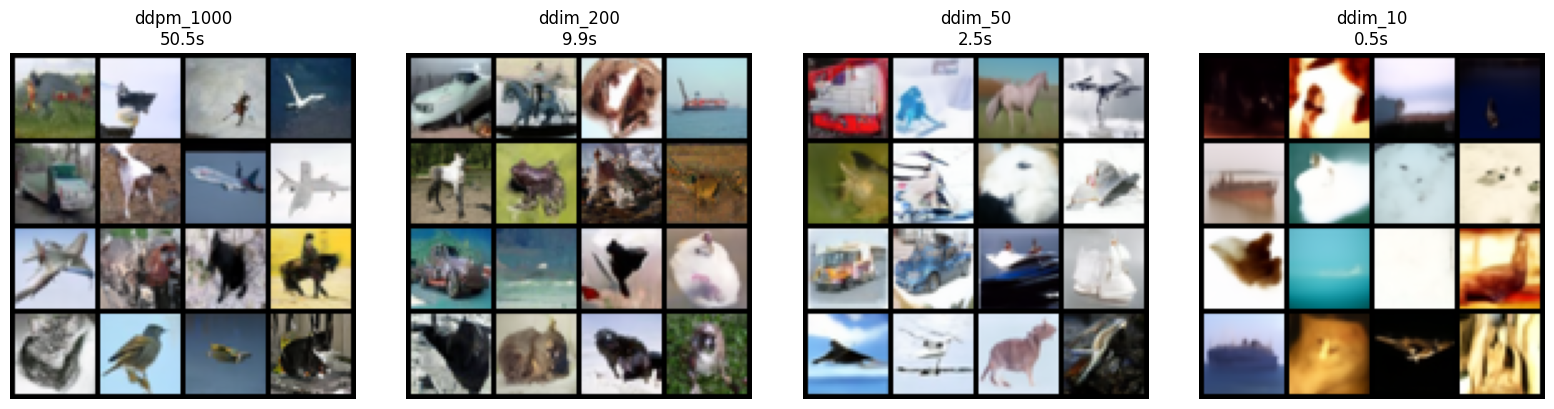

In [13]:
fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 4))
for ax, (name, (elapsed, imgs)) in zip(axes, results.items()):
    ax.imshow(tensor_to_image_grid(imgs, nrow=4))
    ax.set_title(f"{name}\n{elapsed:.1f}s")
    ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/speed_quality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Class-Specific Fine-Tuning

Fine-tune on a single class (e.g. `automobile`) to see whether restricting the
training data produces more consistent / higher-fidelity samples for that class,
at the cost of losing the ability to generate other classes.

In [16]:
!python train.py \
    --schedule cosine \
    --classes automobile \
    --epochs 30 \
    --lr 5e-5 \
    --batch_size 32 \
    --output_dir outputs

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Using device: cuda
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
[cosine_automobile] epoch 0 step 0 loss 0.1193  lr 5.00e-05
[cosine_automobile] epoch 0 step 50 loss 0.0443  lr 5.00e-05
[cosine_automobile] epoch 0 step 100 loss 0.0612  lr 4.99e-05
[cosine_automobile] epoch 0 step 150 loss 0.0489  lr 4.99e-05
[cosine_automobile] epoch 0 avg loss 0.0644
[cosine_automobile] epoch 1 step 0 loss 0.0639  lr 4.99e-05
[cosine_automobile] epoch 1 step 50 loss 0.0522  lr 4.98e-05
[cosine_aut

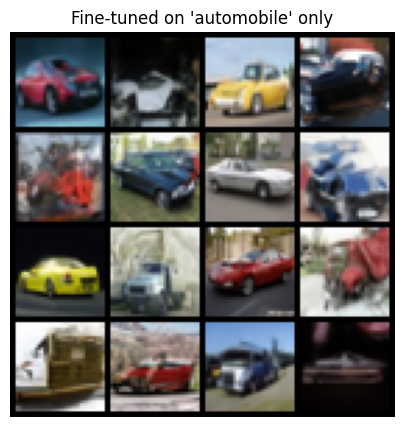

In [17]:
car_model = DiffusionModel(schedule="cosine", num_timesteps=1000, pretrained=True, device=device)
car_model.unet.load_state_dict(torch.load("outputs/unet_cosine_automobile.pt", map_location=device))
car_model.eval()

car_samples = car_model.sample_ddim(num_images=16, num_inference_steps=50)
plt.figure(figsize=(5,5))
plt.imshow(tensor_to_image_grid(car_samples, nrow=4)); plt.axis("off")
plt.title("Fine-tuned on 'automobile' only")
plt.savefig("outputs/class_specific_automobile.png", dpi=150, bbox_inches="tight")
plt.show()